In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = '/content/drive/MyDrive/case_study_2/data/elektrik_veri_hashed.xlsx'
xls = pd.ExcelFile(file_path)

In [4]:
df_tahsilat = pd.read_excel(xls, sheet_name='Tahsilat')
df_tahsilat_1 = pd.read_excel(xls, sheet_name='Tahsilat 1')
df_tahakkuk = pd.read_excel(xls, sheet_name='Tahakkuk')
df_tahakkuk_1 = pd.read_excel(xls, sheet_name='Tahakkuk 1')
df_tahakkuk_2 = pd.read_excel(xls, sheet_name='Tahakkuk 2')

In [5]:
df_tahakkuk_tumu = pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2])

In [7]:
print(df_tahsilat.shape)
print(df_tahsilat_1.shape)
print(df_tahakkuk_tumu.shape)

(636993, 9)
(917632, 22)
(1185698, 10)


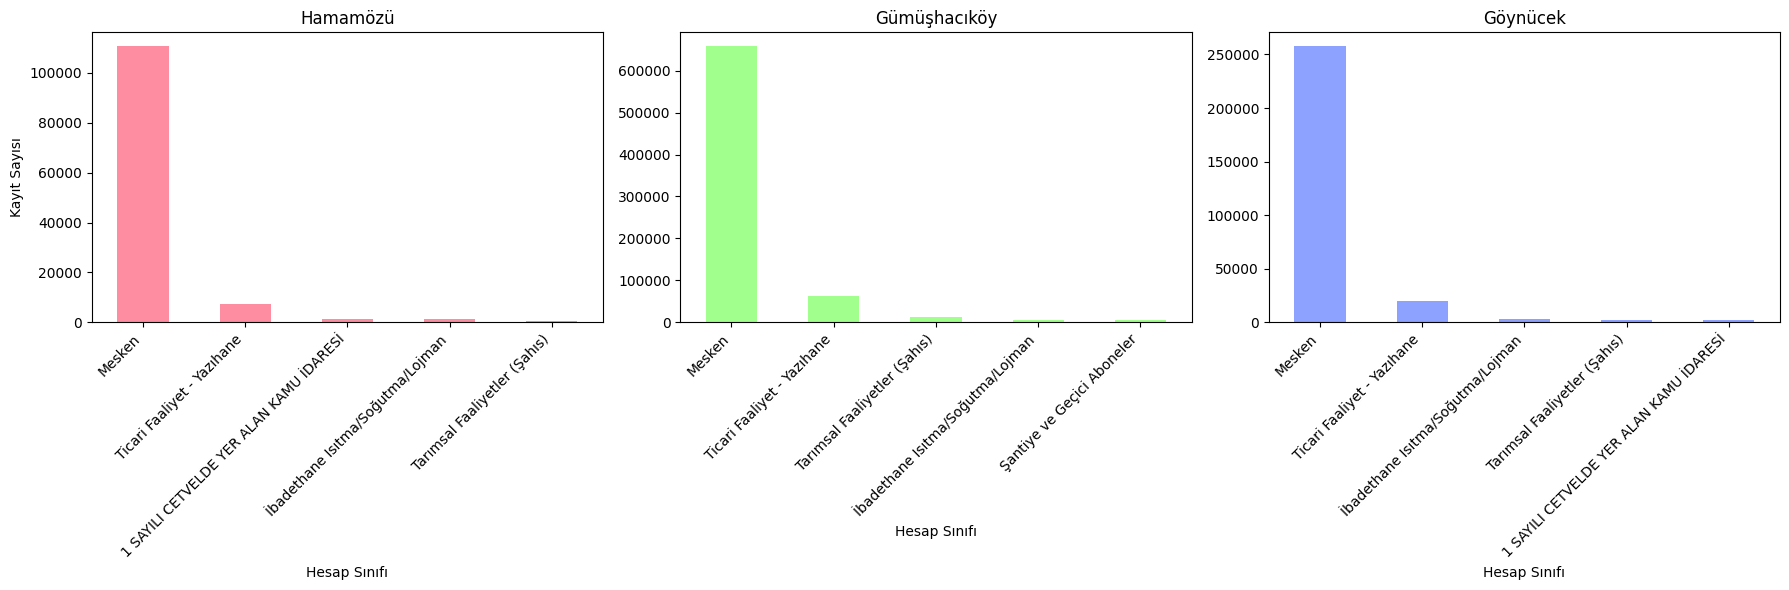

In [22]:
#hesap sınıf dağılımı subplot gösterimi

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

df_tahakkuk['Hesap Sınıfı'].value_counts().head(5).plot(kind='bar', ax=ax1, color='#FF8DA1')
ax1.set_title('Hamamözü')
ax1.set_ylabel('Kayıt Sayısı')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

df_tahakkuk_1['Hesap Sınıfı'].value_counts().head(5).plot(kind='bar', ax=ax2, color='#A1FF8D')
ax2.set_title('Gümüşhacıköy')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

df_tahakkuk_2['Hesap Sınıfı'].value_counts().head(5).plot(kind='bar', ax=ax3, color='#8DA1FF')
ax3.set_title('Göynücek')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('ilce_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

Her 3 ilçede de Mesken çoğunlukta, ikinci sırada her yerde Ticari Faaliyet - Yazıhane.Sıralama üç ilçede de neredeyse aynı, yani hesap sınıfı kompozisyonu ilçeler arasında çok farklılaşmıyor.

In [23]:
df_tahakkuk_tumu['mali_yil_donem'] = pd.to_datetime(df_tahakkuk_tumu['mali_yil_donem'])
df_tahakkuk_tumu['ay'] = df_tahakkuk_tumu['mali_yil_donem'].dt.month


#ay bazlı dağılım.
aylik_ortalama = df_tahakkuk_tumu.pivot_table(index='ay', columns='ilce', values='kwh', aggfunc='mean')
aylik_ortalama

ilce,GÖYNÜCEK,GÜMÜŞHACIKÖY,HAMAMÖZÜ
ay,,,
1,71.727193,90.125893,73.534403
2,66.219465,83.659150,65.242653
3,75.583227,90.309883,69.378002
4,79.906542,93.759577,66.193618
5,77.440839,84.812281,66.700636
6,118.683910,108.061115,71.609768
7,140.941444,140.082910,78.383162
8,126.582059,113.671397,77.410581
9,92.202175,90.539618,70.389814


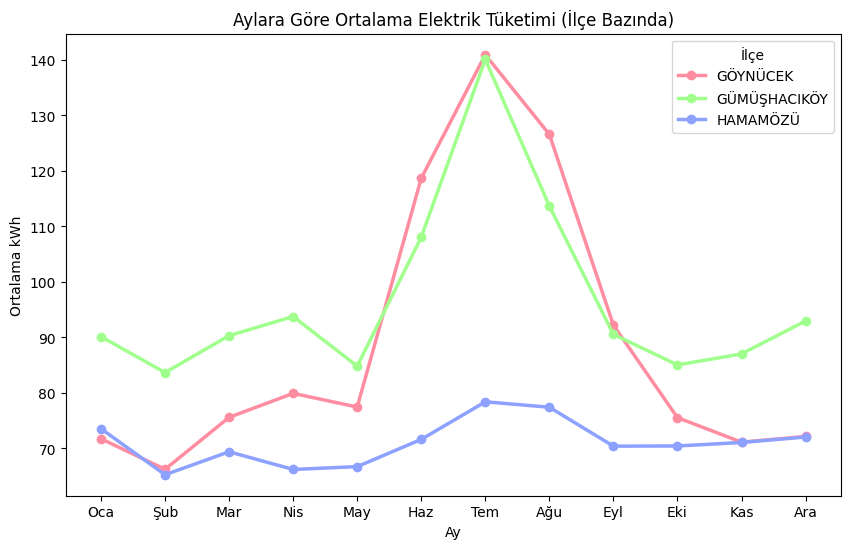

In [14]:

renkler = ['#FF8DA1', '#A1FF8D', '#8DA1FF']
ay_isimleri = ['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz', 'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara']

aylik_ortalama.plot(kind='line', figsize=(10, 6), color=renkler, marker='o', linewidth=2.5)
plt.title('Aylara Göre Ortalama Elektrik Tüketimi (İlçe Bazında)')
plt.xlabel('Ay')
plt.ylabel('Ortalama kWh')
plt.xticks(ticks=range(1, 13), labels=ay_isimleri)
plt.legend(title='İlçe')
plt.savefig('mevsimsel_tuketim.png', dpi=150, bbox_inches='tight')
plt.show()

 * Genel olarak Gümüşhacıköy en yüksek tüketimli ilçe (Ocak-Mayıs, Ekim-Aralık döneminde),ama Haziran-Eylül aylarında Göynücek onu geçiyor. Hamamözü, yaz ayları hariç Göynücek'e yakın seyrediyor, kışın hatta bazen onu geçiyor.
* Yaz aylarında Gümüşhacıköy ve Göynücek'te belirgin bir zirve var, Hamamözü'nde neredeyse yok bu muhtemelen yaz aylarında artan klima kullanımından kaynaklanıyor.

In [26]:
mevsim_haritasi = {
    12: 'Kış', 1: 'Kış', 2: 'Kış',
    3: 'İlkbahar', 4: 'İlkbahar', 5: 'İlkbahar',
    6: 'Yaz', 7: 'Yaz', 8: 'Yaz',
    9: 'Sonbahar', 10: 'Sonbahar', 11: 'Sonbahar'
}

df_tahakkuk_tumu['mevsim'] = df_tahakkuk_tumu['ay'].map(mevsim_haritasi)

mevsimsel_ortalama = df_tahakkuk_tumu.pivot_table(index='mevsim', columns='ilce', values='kwh', aggfunc='mean')
mevsimsel_ortalama = mevsimsel_ortalama.reindex(['Kış', 'İlkbahar', 'Yaz', 'Sonbahar'])
mevsimsel_ortalama

ilce,GÖYNÜCEK,GÜMÜŞHACIKÖY,HAMAMÖZÜ
mevsim,,,
Kış,69.795956,88.451074,70.069664
İlkbahar,77.662317,89.597162,67.406630
Yaz,129.039577,121.489361,75.623238
Sonbahar,79.697450,87.545289,70.618449


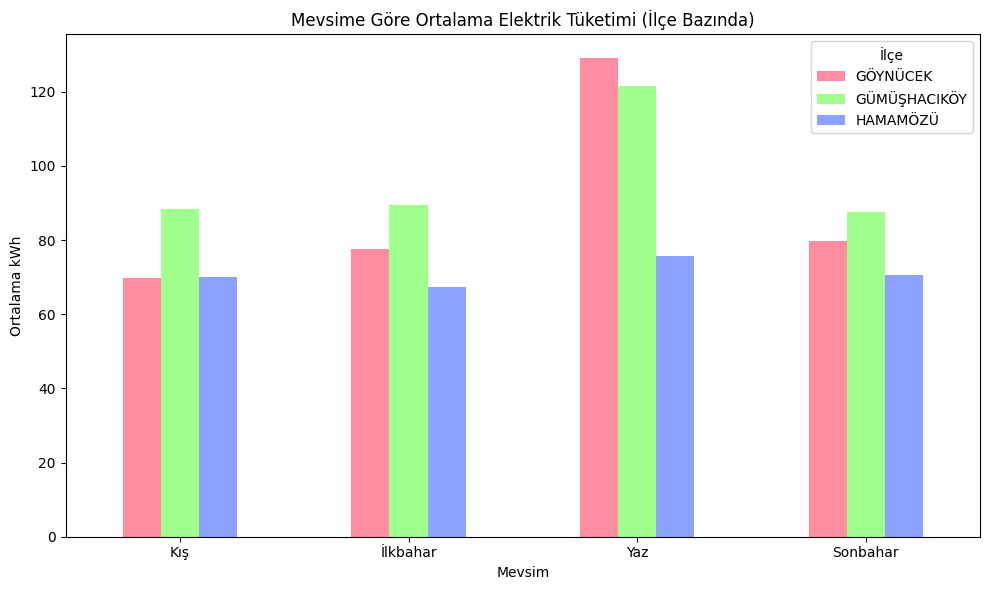

In [25]:
renkler = ['#FF8DA1', '#A1FF8D', '#8DA1FF']

mevsimsel_ortalama.plot(kind='bar', figsize=(10, 6), color=renkler)
plt.title('Mevsime Göre Ortalama Elektrik Tüketimi (İlçe Bazında)')
plt.xlabel('Mevsim')
plt.ylabel('Ortalama kWh')
plt.xticks(rotation=0)
plt.legend(title='İlçe')
plt.tight_layout()
plt.savefig('mevsimsel_ortalama_bar.png', dpi=150, bbox_inches='tight')
plt.show()

* Yazın fark en belirgin hale geliyor: Göynücek 129.0, Gümüşhacıköy 121.5, Hamamözü sadece 75.6.
* Kış, ilkbahar ve sonbaharda üç ilçe birbirine daha yakın (Hamamözü hep 67-70 aralığında,neredeyse hiç değişmiyor).

In [14]:
df_tahsilat['Şube'].value_counts().head(15)

,count
Şube,
AKTİFBANK,193135
ZİRAAT,117521
İŞBANK,87383
HALKBANK,60890
PTT,48760
Y.KREDİ,22528
GARANTİ,21221
AKBANK,20618
VAKIFLAR,14900


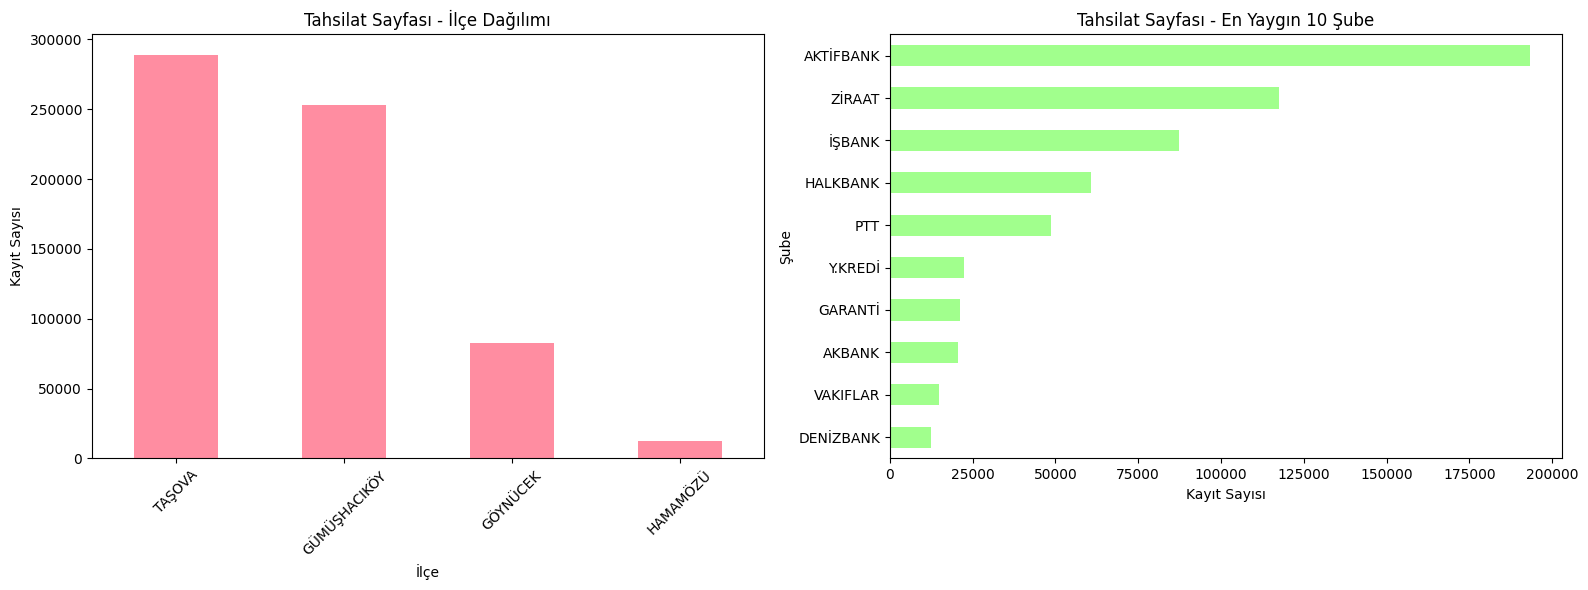

In [15]:
#ilçe ve şuba dağılımları

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ilce_dagilimi = df_tahsilat['İlçe'].value_counts()
ilce_dagilimi.plot(kind='bar', ax=ax1, color='#FF8DA1', rot=45)
ax1.set_title('Tahsilat Sayfası - İlçe Dağılımı')
ax1.set_ylabel('Kayıt Sayısı')

sube_dagilimi = df_tahsilat['Şube'].value_counts().head(10)
sube_dagilimi.plot(kind='barh', ax=ax2, color='#A1FF8D')
ax2.set_title('Tahsilat Sayfası - En Yaygın 10 Şube')
ax2.set_xlabel('Kayıt Sayısı')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('tahsilat_ilce_sube.png', dpi=150, bbox_inches='tight')
plt.show()

* İlçe dağılımında Taşova en çok kayıtlı ilçe, ama Taşova'nın tüketim verisi yok.Bu daha önce fark ettiğimiz kapsam farkını burada da görüyoruz.
* Şube dağılımında Aktifbank açık ara en çok kullanılan kanal, devlet bankası Ziraat'in bile önünde şirketin Aktifbank ile özel bir tahsilat anlaşması olabilir.

In [31]:
tahsilat_ilce_sayilari = df_tahsilat['İlçe'].value_counts()

musteri_sayilari = pd.Series({
    'HAMAMÖZÜ': hamamozu_musteri,
    'GÜMÜŞHACIKÖY': gumushacikoy_musteri,
    'GÖYNÜCEK': goynucek_musteri
})

karsilastirma = pd.DataFrame({
    'tahsilat_kayit_sayisi': tahsilat_ilce_sayilari,
    'musteri_sayisi': musteri_sayilari
}).dropna()

karsilastirma['odeme_musteri_basina'] = karsilastirma['tahsilat_kayit_sayisi'] / karsilastirma['musteri_sayisi']
karsilastirma

,tahsilat_kayit_sayisi,musteri_sayisi,odeme_musteri_basina
GÖYNÜCEK,82519,7128.0,11.576740
GÜMÜŞHACIKÖY,252818,18190.0,13.898736
HAMAMÖZÜ,12579,2981.0,4.219725


Hamamözü'de müşteri başına ödeme kaydı çok daha az: 4.22 iken diğer ilçelerde 11-14 arası.
Yani Hamamözü'de daha önce gördüğümüz düşük tüketim ve az müşteri sayısına, düşük ödeme sıklığı da ekleniyor. Genel olarak "az hareketli" bir ilçe profili.


In [16]:
zamaninda_sayisi = (df_tahsilat_1['Son Ödeme Tarihinden Önceki Tahsilat'].notna() | df_tahsilat_1['Son Ödeme Tarihindeki Tahsilat'].notna()).sum()
toplam_kayit = len(df_tahsilat_1)
zamaninda_orani = zamaninda_sayisi / toplam_kayit * 100

print("Zamanında/erken ödenen kayıt sayısı:", zamaninda_sayisi)
print("Zamanında/erken ödeme oranı: %", round(zamaninda_orani, 1))

Zamanında/erken ödenen kayıt sayısı: 789588
Zamanında/erken ödeme oranı: % 86.0


In [17]:
gec_sutunlari = ['Son Ödeme (1)', 'Son Ödeme (2)', 'Son Ödeme (3)', 'Son Ödeme (4)', 'Son Ödeme (5)',
                  'Son Ödeme (6-10)', 'Son Ödeme (10-20)', 'Son Ödeme (20-30)', 'Son Ödeme (30-60)',
                  'Son Ödeme (60-90)', 'Son Ödeme (90-120)', 'Son Ödeme (120-150)', 'Son Ödeme (150-180)',
                  'Son Ödeme (180+)']

gec_sayisi = df_tahsilat_1[gec_sutunlari].notna().any(axis=1).sum()
gec_orani = gec_sayisi / toplam_kayit * 100

print("Geç ödenen kayıt sayısı:", gec_sayisi)
print("Geç ödeme oranı: %", round(gec_orani, 1))

Geç ödenen kayıt sayısı: 249487
Geç ödeme oranı: % 27.2


In [18]:
#sadece zamanında ve geç olarak oranları hesapladık.
zamaninda_sayisi = (df_tahsilat_1['Son Ödeme Tarihinden Önceki Tahsilat'].notna() | df_tahsilat_1['Son Ödeme Tarihindeki Tahsilat'].notna()).sum()
toplam_kayit = len(df_tahsilat_1)

gec_sutunlari = ['Son Ödeme (1)', 'Son Ödeme (2)', 'Son Ödeme (3)', 'Son Ödeme (4)', 'Son Ödeme (5)',
                  'Son Ödeme (6-10)', 'Son Ödeme (10-20)', 'Son Ödeme (20-30)', 'Son Ödeme (30-60)',
                  'Son Ödeme (60-90)', 'Son Ödeme (90-120)', 'Son Ödeme (120-150)', 'Son Ödeme (150-180)',
                  'Son Ödeme (180+)']
gec_sayisi = df_tahsilat_1[gec_sutunlari].notna().any(axis=1).sum()

print("Zamanında/erken:", zamaninda_sayisi, "- %", round(zamaninda_sayisi/toplam_kayit*100, 1))
print("Geç:", gec_sayisi, "- %", round(gec_sayisi/toplam_kayit*100, 1))


Zamanında/erken: 789588 - % 86.0
Geç: 249487 - % 27.2


In [32]:
#kısmi, zamanında ve geç olarak hesapladık
zamaninda_mask = df_tahsilat_1['Son Ödeme Tarihinden Önceki Tahsilat'].notna() | df_tahsilat_1['Son Ödeme Tarihindeki Tahsilat'].notna()
gec_mask = df_tahsilat_1[gec_sutunlari].notna().any(axis=1)

sadece_zamaninda = (zamaninda_mask & ~gec_mask).sum()
sadece_gec = (gec_mask & ~zamaninda_mask).sum()
kismi_odeme = (zamaninda_mask & gec_mask).sum()

print("Sadece zamanında/erken:", sadece_zamaninda)
print("Sadece geç:", sadece_gec)
print("Kısmi ödeme (ikisi de var):", kismi_odeme)

Sadece zamanında/erken: 666311
Sadece geç: 126210
Kısmi ödeme (ikisi de var): 123277


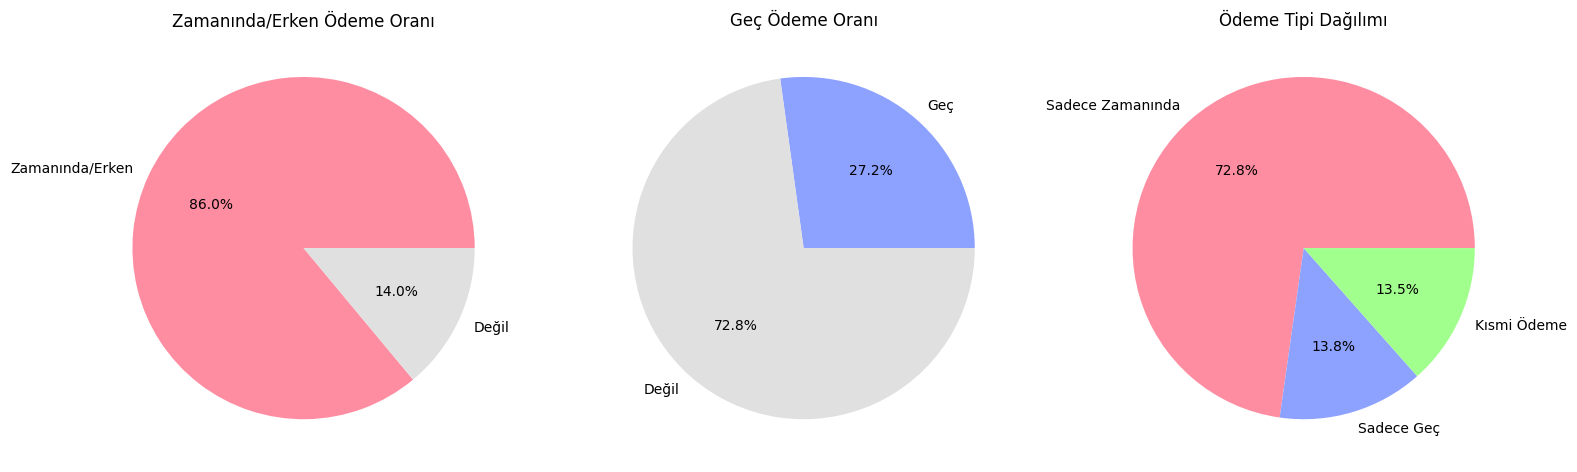

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

ax1.pie([zamaninda_sayisi, toplam_kayit - zamaninda_sayisi], labels=['Zamanında/Erken', 'Değil'], autopct='%1.1f%%', colors=['#FF8DA1', '#E0E0E0'])
ax1.set_title('Zamanında/Erken Ödeme Oranı')

ax2.pie([gec_sayisi, toplam_kayit - gec_sayisi], labels=['Geç', 'Değil'], autopct='%1.1f%%', colors=['#8DA1FF', '#E0E0E0'])
ax2.set_title('Geç Ödeme Oranı')

ax3.pie([sadece_zamaninda, sadece_gec, kismi_odeme], labels=['Sadece Zamanında', 'Sadece Geç', 'Kısmi Ödeme'], autopct='%1.1f%%', colors=['#FF8DA1', '#8DA1FF', '#A1FF8D'])
ax3.set_title('Ödeme Tipi Dağılımı')

plt.tight_layout()
plt.savefig('odeme_zamanlamasi.png', dpi=150, bbox_inches='tight')
plt.show()

Müşteriler genelde zamanında öderken , sadece geç  ve kısmi ödeme birbirine oldukça yakın çıktı.kayıtların yaklaşık dörtte biri bir şekilde gecikme içeriyor (sadece geç + kısmi). Kısmi ödeme grubu da azımsanmayacak kadar büyük: bu müşteriler faturalarının bir kısmını zamanında, bir kısmını geç ödemiş.

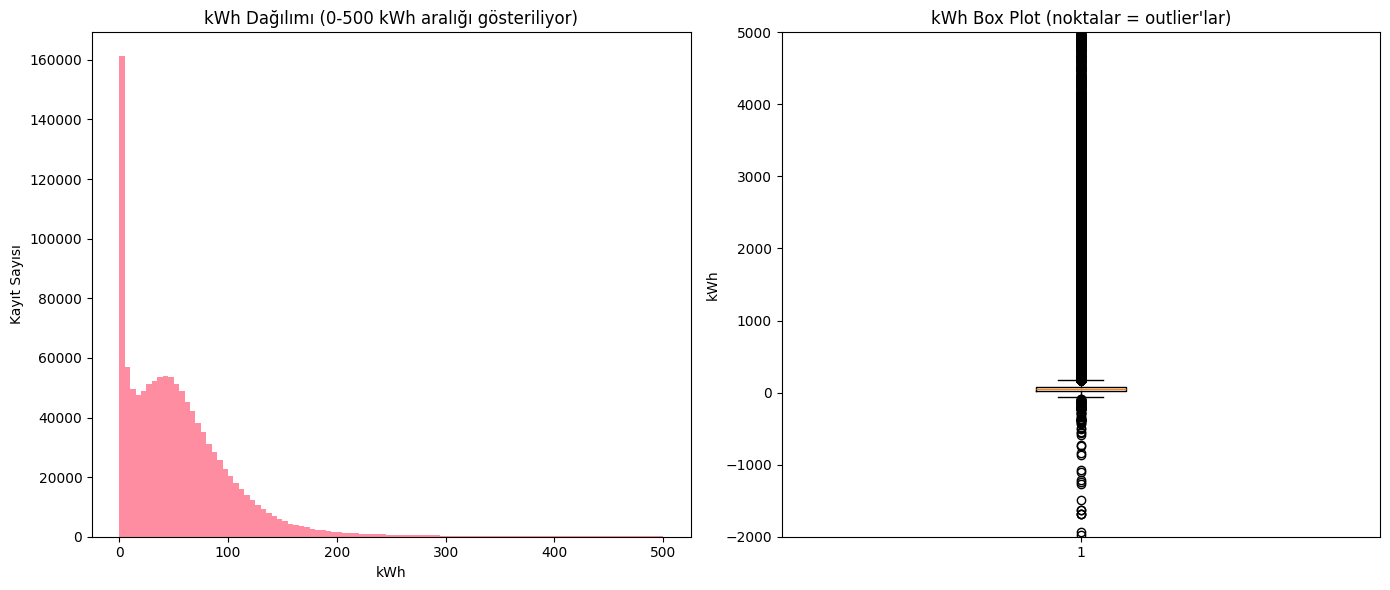

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(df_tahakkuk_tumu['kwh'], bins=100, range=(0, 500), color='#FF8DA1')
ax1.set_title('kWh Dağılımı (0-500 kWh aralığı gösteriliyor)')
ax1.set_xlabel('kWh')
ax1.set_ylabel('Kayıt Sayısı')

ax2.boxplot(df_tahakkuk_tumu['kwh'], vert=True)
ax2.set_title("kWh Box Plot (noktalar = outlier'lar)")
ax2.set_ylabel('kWh')
ax2.set_ylim(-2000, 5000)

plt.tight_layout()
plt.savefig('kwh_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

Histogram sağa çarpık (right-skewed) — çoğu kayıt 0-150 kWh aralığında yoğunlaşıyor, yüksek kWh'lere doğru gidildikçe kayıt sayısı hızla azalıyor. Box plot'taki çok sayıda nokta, daha önce IQR ile bulduğumuz 48,554 outlier'ı görsel olarak doğruluyor.üst sınırın üzerinde yoğun bir yığılma var.